In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in data, here the top protein and TRN combos with relevant cluster (RFI) IDs
df = pd.read_csv('data/top_protein_pathway_combos_clusterid.csv')

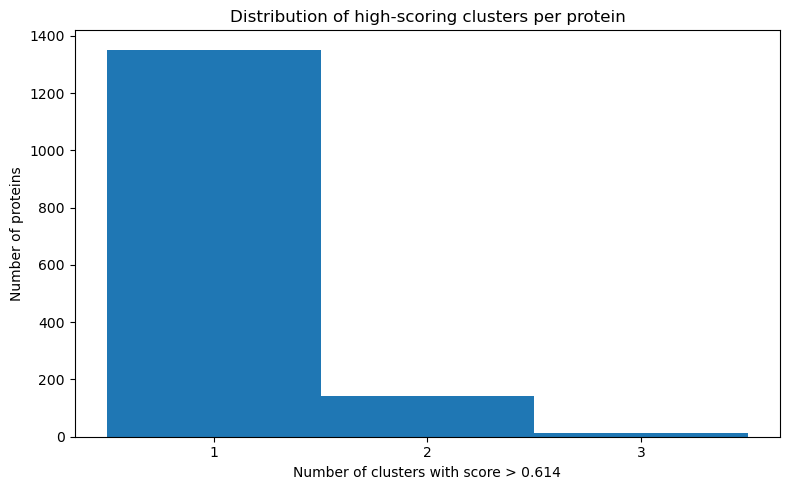

In [3]:
# Filter rows where score exceeds threshold and count unique clusters per protein
clusters_per_protein = (
    df.loc[df["score"] > 0.612]          
      .groupby("protein")["cluster_id"]  
      .nunique()                         
)

# Count how many proteins have 0, 1, 2, ... high-scoring clusters
counts = clusters_per_protein.value_counts().sort_index()

# Convert index and values to plain numeric arrays for plotting
x = counts.index.to_numpy(dtype=int) 
y = counts.to_numpy(dtype=int)        

# Create bar plot
plt.figure(figsize=(8, 5))
plt.bar(x, y, width=1)

# Label axes and title
plt.xlabel("Number of clusters with score > 0.614")
plt.ylabel("Number of proteins")
plt.title("Distribution of high-scoring clusters per protein")

# Set x-axis ticks to match cluster counts
plt.xticks(x)

# Show plot
plt.tight_layout()
plt.show()